In [2]:
pip install yfinance prophet pandas matplotlib scikit-learn

In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Define the cryptocurrencies and their Yahoo Finance tickers
cryptos = {
    'Bitcoin': 'BTC-USD',
    'Ethereum': 'ETH-USD',
    'Tether': 'USDT-USD'
}

# Define the date range for historical data (e.g., last 5 years)
start_date = '2019-01-01'
end_date = pd.to_datetime('today').strftime('%Y-%m-%d')

# Dictionary to store data for each crypto
crypto_data = {}

print(f"Fetching historical data from {start_date} to {end_date}...")

for name, ticker in cryptos.items():
    print(f"Downloading {name} ({ticker})...")
    df = yf.download(ticker, start=start_date, end=end_date)
    if not df.empty:
        crypto_data[name] = df
        print(f"Successfully downloaded {len(df)} rows for {name}.")
    else:
        print(f"Could not download data for {name}.")

print("Data fetching complete.")

Fetching historical data from 2019-01-01 to 2026-05-14...


/tmp/ipykernel_11283/3864937599.py:26: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_11283/3864937599.py:26: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)


Successfully downloaded 2689 rows for Bitcoin.


[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_11283/3864937599.py:26: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)


Successfully downloaded 2689 rows for Ethereum.


[*********************100%***********************]  1 of 1 completed

Successfully downloaded 2689 rows for Tether.
Data fetching complete.


Bitcoin Forecast (Bullish Scenario):


,ds,yhat,yhat_lower,yhat_upper
2774,2026-08-06,103894.549025,90494.604007,116966.362616
2775,2026-08-07,103977.764253,89690.381661,117199.165826
2776,2026-08-08,104010.047461,89551.193225,117945.672974
2777,2026-08-09,104084.682705,89600.648062,117209.402426
2778,2026-08-10,104238.057588,89152.431958,118099.975922


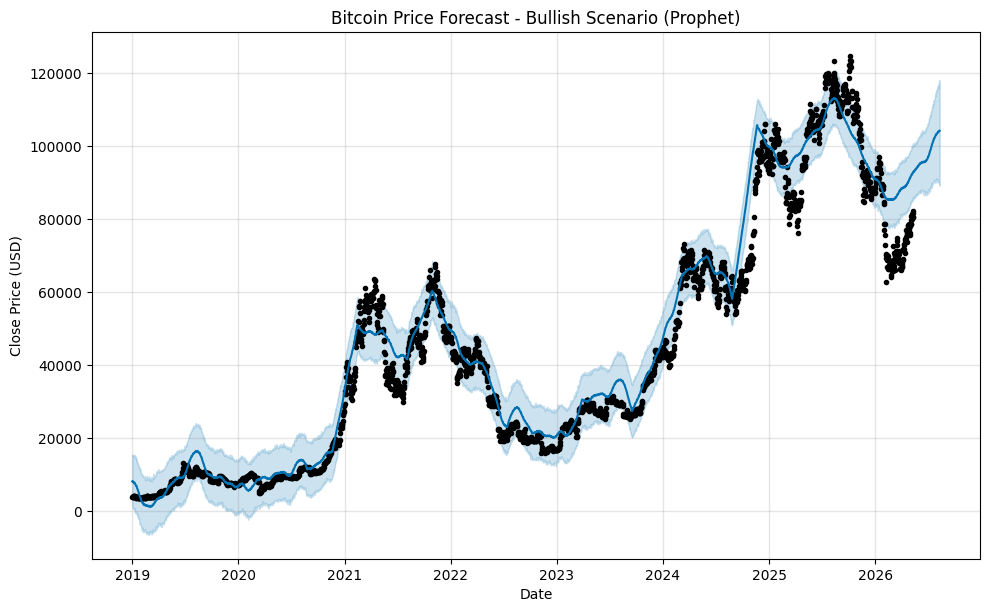

In [4]:
if 'Bitcoin' in crypto_data:
    btc_df_scenario = crypto_data['Bitcoin'].reset_index()
    btc_df_scenario = btc_df_scenario[['Date', 'Close']]
    btc_df_scenario.columns = ['ds', 'y']

    # Scenario 1: Bullish Market
    model_bullish = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.15 # Higher flexibility for trend changes
    )

    # Add a hypothetical bullish regressor
    # For this example, we'll add a simple linear increase. In a real scenario, this would be based on external data.
    def add_bullish_regressor(df):
        df['bullish_factor'] = np.linspace(0, 5000, len(df)) # Add an increasing factor over time
        return df

    btc_df_scenario_bullish = add_bullish_regressor(btc_df_scenario.copy())
    model_bullish.add_regressor('bullish_factor')

    model_bullish.fit(btc_df_scenario_bullish)

    future_bullish = model_bullish.make_future_dataframe(periods=90)
    future_bullish = add_bullish_regressor(future_bullish)

    forecast_bullish = model_bullish.predict(future_bullish)

    print("Bitcoin Forecast (Bullish Scenario):")
    display(forecast_bullish[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

    fig_bullish = model_bullish.plot(forecast_bullish)
    plt.title('Bitcoin Price Forecast - Bullish Scenario (Prophet)')
    plt.xlabel('Date')
    plt.ylabel('Close Price (USD)')
    plt.show()
else:
    print("Bitcoin data not available for scenario analysis.")

Bitcoin Forecast (Bearish Scenario):


,ds,yhat,yhat_lower,yhat_upper
2774,2026-08-06,104009.235236,88580.239631,119400.251869
2775,2026-08-07,104042.220594,88578.204298,119668.209170
2776,2026-08-08,104024.347517,88024.069929,120070.939150
2777,2026-08-09,104048.635078,88570.077840,119511.845567
2778,2026-08-10,104154.456508,87657.368655,120003.600688


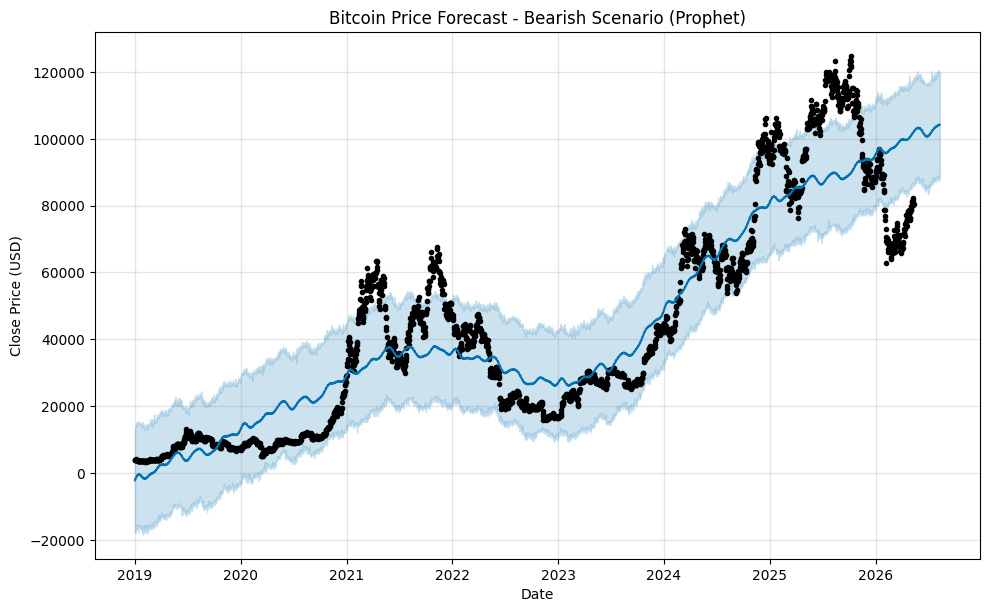

In [5]:
if 'Bitcoin' in crypto_data:
    btc_df_scenario = crypto_data['Bitcoin'].reset_index()
    btc_df_scenario = btc_df_scenario[['Date', 'Close']]
    btc_df_scenario.columns = ['ds', 'y']

    # Scenario 2: Bearish Market
    model_bearish = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.01 # Lower flexibility for trend changes
    )

    # Add a hypothetical bearish regressor
    def add_bearish_regressor(df):
        df['bearish_factor'] = np.linspace(0, -3000, len(df)) # Add a decreasing factor over time
        return df

    btc_df_scenario_bearish = add_bearish_regressor(btc_df_scenario.copy())
    model_bearish.add_regressor('bearish_factor')

    model_bearish.fit(btc_df_scenario_bearish)

    future_bearish = model_bearish.make_future_dataframe(periods=90)
    future_bearish = add_bearish_regressor(future_bearish)

    forecast_bearish = model_bearish.predict(future_bearish)

    print("Bitcoin Forecast (Bearish Scenario):")
    display(forecast_bearish[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

    fig_bearish = model_bearish.plot(forecast_bearish)
    plt.title('Bitcoin Price Forecast - Bearish Scenario (Prophet)')
    plt.xlabel('Date')
    plt.ylabel('Close Price (USD)')
    plt.show()
else:
    print("Bitcoin data not available for scenario analysis.")

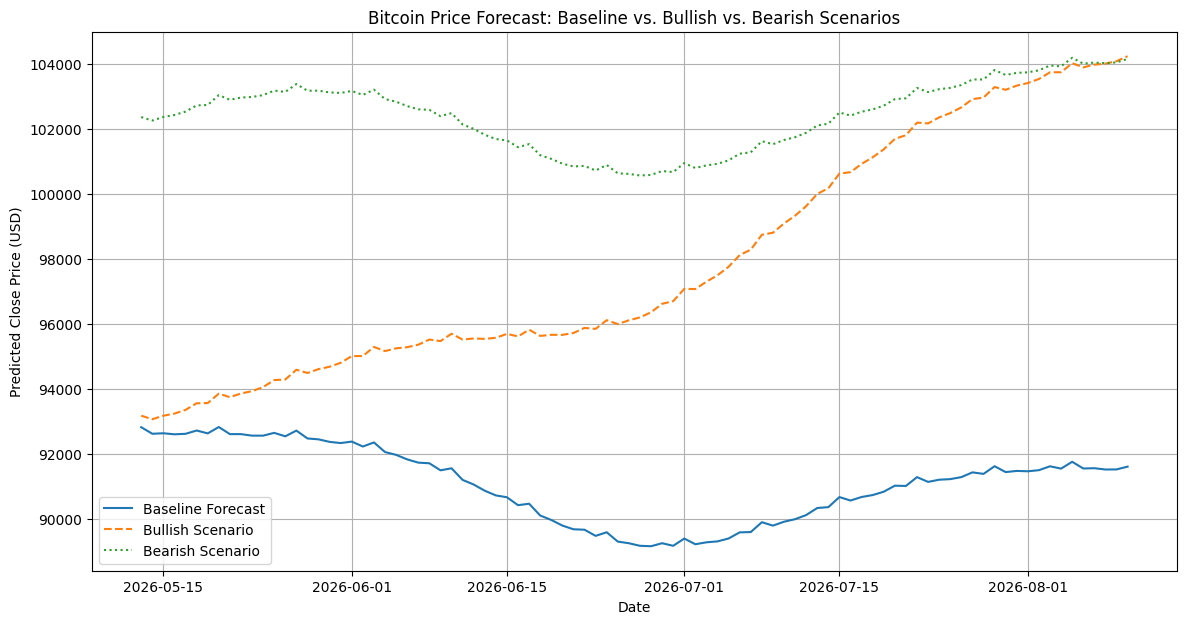

In [6]:
if 'Bitcoin' in crypto_data:
    # Re-run baseline forecast for comparison
    btc_df_baseline = crypto_data['Bitcoin'].reset_index()
    btc_df_baseline = btc_df_baseline[['Date', 'Close']]
    btc_df_baseline.columns = ['ds', 'y']

    model_baseline = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.05
    )
    model_baseline.fit(btc_df_baseline)
    future_baseline = model_baseline.make_future_dataframe(periods=90)
    forecast_baseline = model_baseline.predict(future_baseline)

    # Get the last 90 days of forecasts for comparison
    forecast_baseline_90 = forecast_baseline[['ds', 'yhat']].tail(90).set_index('ds')
    forecast_bullish_90 = forecast_bullish[['ds', 'yhat']].tail(90).set_index('ds')
    forecast_bearish_90 = forecast_bearish[['ds', 'yhat']].tail(90).set_index('ds')

    plt.figure(figsize=(14, 7))
    plt.plot(forecast_baseline_90.index, forecast_baseline_90['yhat'], label='Baseline Forecast')
    plt.plot(forecast_bullish_90.index, forecast_bullish_90['yhat'], label='Bullish Scenario', linestyle='--')
    plt.plot(forecast_bearish_90.index, forecast_bearish_90['yhat'], label='Bearish Scenario', linestyle=':')

    plt.title('Bitcoin Price Forecast: Baseline vs. Bullish vs. Bearish Scenarios')
    plt.xlabel('Date')
    plt.ylabel('Predicted Close Price (USD)')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Cannot perform sensitivity analysis: Bitcoin data not available.")

In [7]:
%%writefile streamlit_app.py

import streamlit as st
import yfinance as yf
import pandas as pd
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly
import plotly.graph_objs as go

# --- Page Configuration ---
st.set_page_config(page_title="Crypto Price Forecast Dashboard", layout="wide")

st.title("Cryptocurrency Price Forecast Dashboard (Bitcoin Only)")
st.write("Forecast Bitcoin price using Prophet.")

# --- Sidebar for User Inputs ---
st.sidebar.header("Configuration")

crypto_options = {
    'Bitcoin': 'BTC-USD'
}

selected_crypto_name = st.sidebar.selectbox(
    "Select Cryptocurrency:",
    list(crypto_options.keys())
)
selected_crypto_ticker = crypto_options[selected_crypto_name]

# Date range for historical data
start_date = st.sidebar.date_input("Start Date", value=pd.to_datetime('2019-01-01'))
end_date = st.sidebar.date_input("End Date", value=pd.to_datetime('today'))

# Forecast horizon
forecast_months = st.sidebar.slider("Forecast Horizon (Months)", min_value=1, max_value=12, value=3)
forecast_days = forecast_months * 30

# Prophet parameters (simplified for dashboard)
changepoint_prior_scale = st.sidebar.slider(
    "Changepoint Prior Scale (Model Flexibility)",
    min_value=0.01, max_value=0.5, value=0.05, step=0.01
)

# --- Data Fetching ---
@st.cache_data(ttl=3600) # Cache data for 1 hour
def fetch_data(ticker, start, end):
    df = yf.download(ticker, start=start, end=end)
    if df.empty:
        return None
    # Use 'Close' price for forecasting
    df = df.reset_index()[['Date', 'Close']]
    df.columns = ['ds', 'y']
    return df

data_load_state = st.info(f"Loading historical data for {selected_crypto_name}...")
initial_data = fetch_data(selected_crypto_ticker, start_date, end_date)
data_load_state.empty()

if initial_data is None:
    st.error(f"Could not fetch data for {selected_crypto_name}. Please check the ticker or date range.")
else:
    st.subheader(f"Historical Data for {selected_crypto_name}")
    st.dataframe(initial_data.tail())

    fig_hist = go.Figure()
    fig_hist.add_trace(go.Scatter(x=initial_data['ds'], y=initial_data['y'], mode='lines', name='Close Price'))
    fig_hist.update_layout(title=f'{selected_crypto_name} Historical Prices', xaxis_title='Date', yaxis_title='Price (USD)')
    st.plotly_chart(fig_hist, use_container_width=True)

    # --- Prophet Model Training and Forecasting ---
    st.subheader(f"Prophet Forecast for {selected_crypto_name}")

    # Train model
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=changepoint_prior_scale
    )
    model.fit(initial_data)

    # Make future dataframe
    future = model.make_future_dataframe(periods=forecast_days)

    # Make predictions
    forecast = model.predict(future)

    st.write(f"Forecast for the next {forecast_months} months:")
    st.dataframe(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

    # Plot forecast
    fig_forecast = plot_plotly(model, forecast)
    fig_forecast.update_layout(
        title=f'{selected_crypto_name} Price Forecast',
        xaxis_title='Date',
        yaxis_title='Price (USD)'
    )
    st.plotly_chart(fig_forecast, use_container_width=True)

    # Plot forecast components
    st.subheader("Forecast Components")
    fig_components = plot_components_plotly(model, forecast)
    st.plotly_chart(fig_components, use_container_width=True)

    st.markdown("--- ")

Writing streamlit_app.py


In [8]:
if 'Bitcoin' in crypto_data:
    print("Bitcoin (BTC-USD) Data Sample:")
    display(crypto_data['Bitcoin'].head())
else:
    print("Bitcoin data not available.")

Bitcoin (BTC-USD) Data Sample:


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2019-01-01,3843.520020,3850.913818,3707.231201,3746.713379,4324200990
2019-01-02,3943.409424,3947.981201,3817.409424,3849.216309,5244856836
2019-01-03,3836.741211,3935.685059,3826.222900,3931.048584,4530215219
2019-01-04,3857.717529,3865.934570,3783.853760,3832.040039,4847965467
2019-01-05,3845.194580,3904.903076,3836.900146,3851.973877,5137609824


Bitcoin data prepared for Prophet:


,ds,y
0,2019-01-01,3843.520020
1,2019-01-02,3943.409424
2,2019-01-03,3836.741211
3,2019-01-04,3857.717529
4,2019-01-05,3845.194580


Bitcoin forecast for the next 90 days:


,ds,yhat,yhat_lower,yhat_upper
2774,2026-08-06,91543.263376,79148.815230,103398.430400
2775,2026-08-07,91552.161592,80115.787828,103195.619583
2776,2026-08-08,91511.789813,79543.558773,103771.276962
2777,2026-08-09,91514.688320,79614.532138,102998.535897
2778,2026-08-10,91600.031890,80051.455596,103900.040405


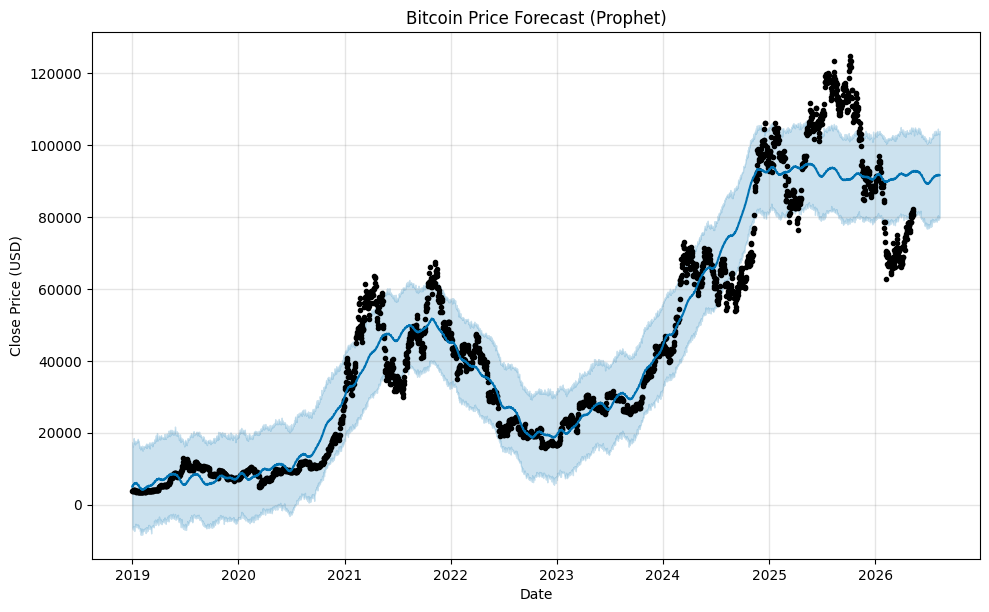

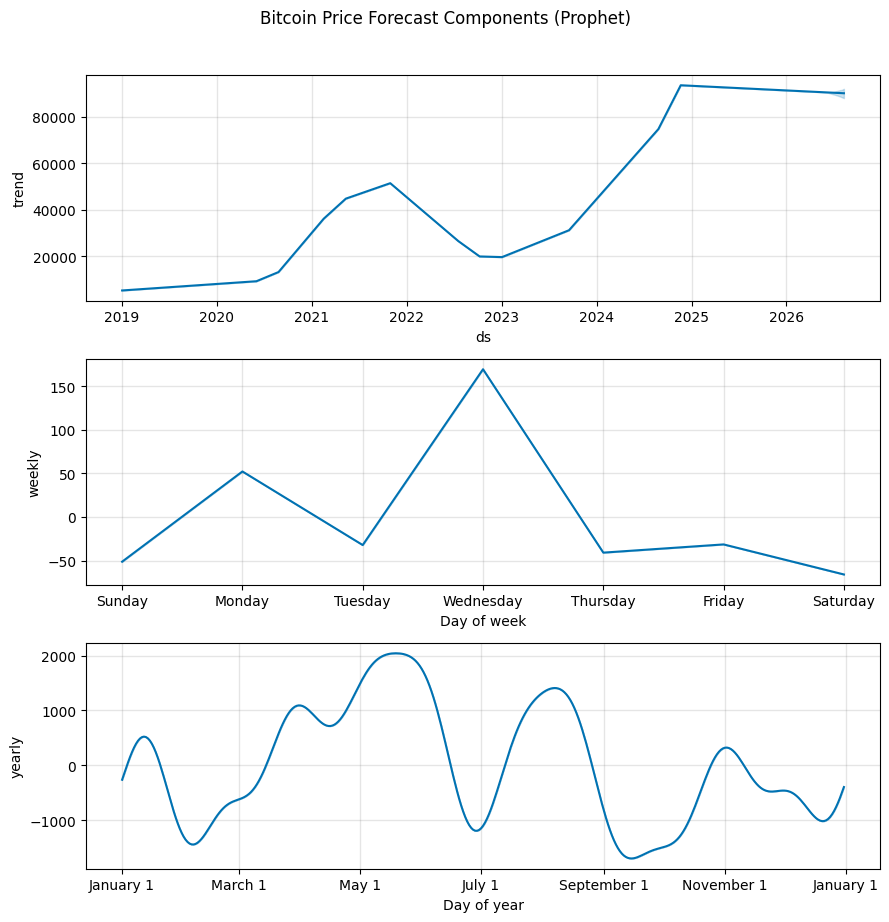

In [9]:
if 'Bitcoin' in crypto_data:
    btc_df = crypto_data['Bitcoin'].reset_index()
    btc_df = btc_df[['Date', 'Close']]
    btc_df.columns = ['ds', 'y']

    print("Bitcoin data prepared for Prophet:")
    display(btc_df.head())

    # Initialize and train the Prophet model
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False, # Daily seasonality is often not relevant for daily data unless there's intra-day patterns
        changepoint_prior_scale=0.05 # Adjusting this can make the model more or less flexible to trend changes
    )
    model.fit(btc_df)

    # Create a future DataFrame for 3 months (approx 90 days) prediction
    future = model.make_future_dataframe(periods=90)

    # Make predictions
    forecast = model.predict(future)

    print("Bitcoin forecast for the next 90 days:")
    display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

    # Plot the forecast
    fig1 = model.plot(forecast)
    plt.title('Bitcoin Price Forecast (Prophet)')
    plt.xlabel('Date')
    plt.ylabel('Close Price (USD)')
    plt.show()

    # Plot the components of the forecast
    fig2 = model.plot_components(forecast)
    plt.suptitle('Bitcoin Price Forecast Components (Prophet)', y=1.02) # Adjust suptitle position
    plt.tight_layout()
    plt.show()
else:
    print("Cannot forecast: Bitcoin data not available.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 32.4 MB/s eta 0:00:00
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2151
Model:               SARIMAX(2, 1, 0)   Log Likelihood              -18255.112
Date:                Thu, 14 May 2026   AIC                          36518.223
Time:                        02:46:22   BIC                          36540.916
Sample:                             0   HQIC                         36526.525
                               - 2151                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     42.4449     25.572      1.660      0.097      -7.676      92.566
ar.L1         -0.0406      0.014     -2.829      0

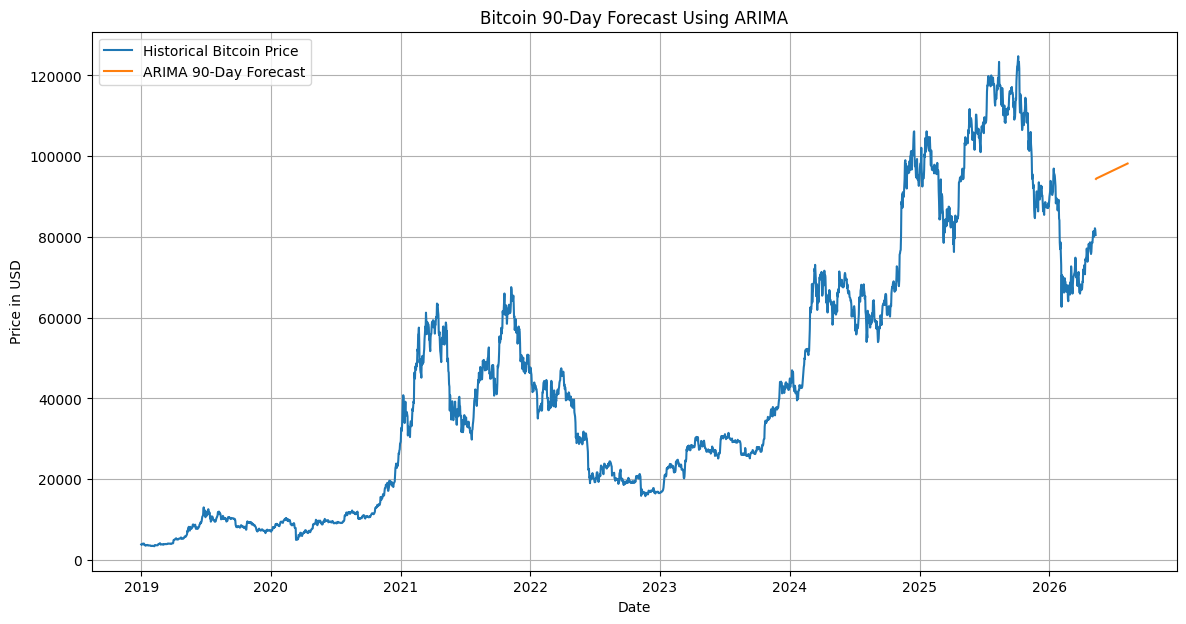

In [10]:
!pip install pmdarima -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Prepare Bitcoin closing price data
btc_arima = crypto_data['Bitcoin'].reset_index()
btc_arima = btc_arima[['Date', 'Close']]
btc_arima.columns = ['ds', 'y']
btc_arima = btc_arima.dropna()

# Train-test split
train_size = int(len(btc_arima) * 0.8)
train = btc_arima.iloc[:train_size]
test = btc_arima.iloc[train_size:]

# Fit ARIMA model
arima_model = auto_arima(
    train['y'],
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore"
)

print(arima_model.summary())

# Forecast test period
arima_test_forecast = arima_model.predict(n_periods=len(test))

# Evaluate ARIMA
arima_mae = mean_absolute_error(test['y'], arima_test_forecast)
arima_rmse = np.sqrt(mean_squared_error(test['y'], arima_test_forecast))

print("ARIMA Model Performance")
print(f"MAE: {arima_mae:.2f}")
print(f"RMSE: {arima_rmse:.2f}")

# Forecast next 90 days
future_arima_forecast = arima_model.predict(n_periods=90)

future_dates = pd.date_range(
    start=btc_arima['ds'].iloc[-1] + pd.Timedelta(days=1),
    periods=90,
    freq='D'
)

arima_future_df = pd.DataFrame({
    'ds': future_dates,
    'arima_forecast': future_arima_forecast
})

# Plot ARIMA forecast
plt.figure(figsize=(14, 7))
plt.plot(btc_arima['ds'], btc_arima['y'], label='Historical Bitcoin Price')
plt.plot(arima_future_df['ds'], arima_future_df['arima_forecast'], label='ARIMA 90-Day Forecast')
plt.title('Bitcoin 90-Day Forecast Using ARIMA')
plt.xlabel('Date')
plt.ylabel('Price in USD')
plt.legend()
plt.grid(True)
plt.show()


--- Bitcoin Prophet Model Performance ---
Mean Absolute Error (MAE): 23623.22
Root Mean Squared Error (RMSE): 30793.62


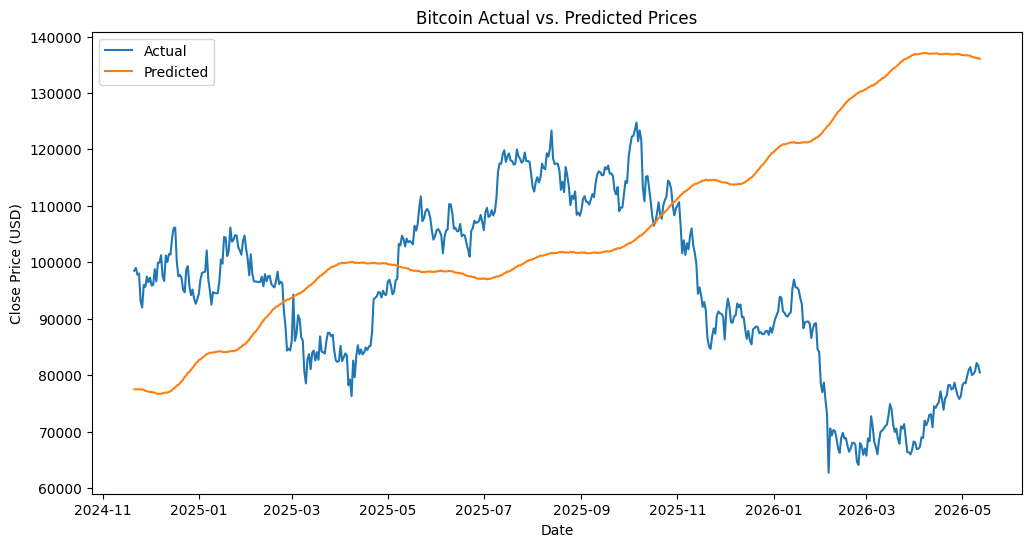

In [11]:
# Function to evaluate model performance
def evaluate_prophet_model(df, crypto_name):
    # Split data into training and testing sets
    train_size = int(len(df) * 0.8)
    train, test = df[0:train_size], df[train_size:len(df)]

    # Train Prophet model
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.05
    )
    model.fit(train)

    # Make predictions on the test set
    future = model.make_future_dataframe(periods=len(test))
    forecast = model.predict(future)

    # Extract actual and predicted values for the test period
    actual = test['y'].values
    predicted = forecast['yhat'].tail(len(test)).values

    # Calculate MAE and RMSE
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    print(f"\n--- {crypto_name} Prophet Model Performance ---")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

    # Plot actual vs. predicted
    plt.figure(figsize=(12, 6))
    plt.plot(test['ds'], actual, label='Actual')
    plt.plot(test['ds'], predicted, label='Predicted')
    plt.title(f'{crypto_name} Actual vs. Predicted Prices')
    plt.xlabel('Date')
    plt.ylabel('Close Price (USD)')
    plt.legend()
    plt.show()

    return {'MAE': mae, 'RMSE': rmse}

# Evaluate Bitcoin
if 'Bitcoin' in crypto_data:
    btc_df_eval = crypto_data['Bitcoin'].reset_index()
    btc_df_eval = btc_df_eval[['Date', 'Close']]
    btc_df_eval.columns = ['ds', 'y']
    btc_metrics = evaluate_prophet_model(btc_df_eval, 'Bitcoin')
else:
    print("Bitcoin data not available for evaluation.")

ECON5380 Group Project Assignment

Project Plan:
Forecast cryptocurrency price of next trading date for 3 months

Group 1 (Weston and Corey) - Bitcoin (BTC): The leading "digital gold" with high institutional adoption, particularly through spot ETFs.


1) Technical requirements
Python notebook (>2 forecasting models(Weston-1 Corey-1))
Model performance comparison

2). Analytical
Scenario design (>2 cases)
Sensitivity analysis (how changes of IV impact DV)
Risk interpretation (1 page writeup)

3) Presentation and Report
Build Streamlit App for executive dashboard
Policy/business recommendation (1 page writeup)
Grading schema

Criteria	Credits
Forecast Performance	5
Scenario Creativity	5
Sensitivity analysis	5
Streamlit dashboard	5
Presentation slides	5

